In [2]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans



df = pd.read_csv("LungCancerDataset.csv")  

X_toScale = df.drop('PULMONARY_DISEASE', axis=1)
y = df['PULMONARY_DISEASE'].map({'NO': 0, 'YES': 1})
scaler = StandardScaler()
X = scaler.fit_transform(X_toScale)


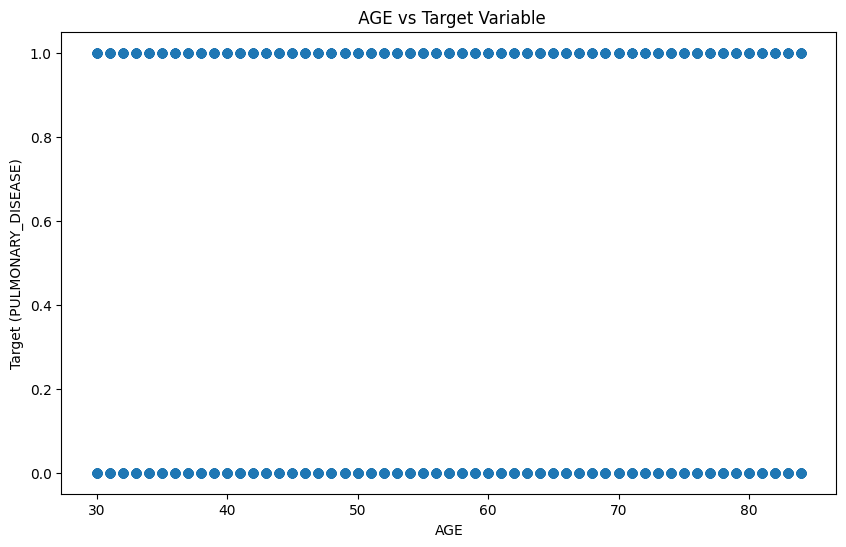

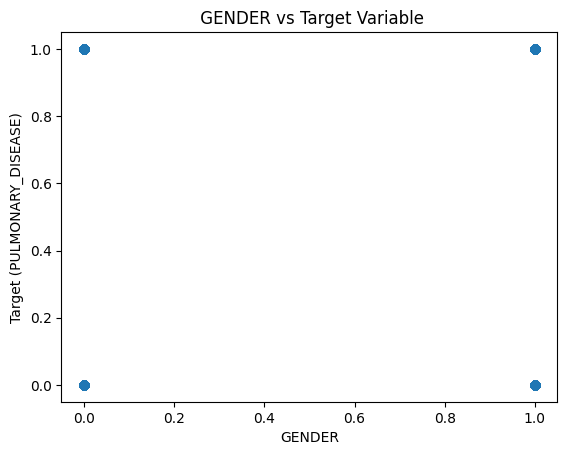

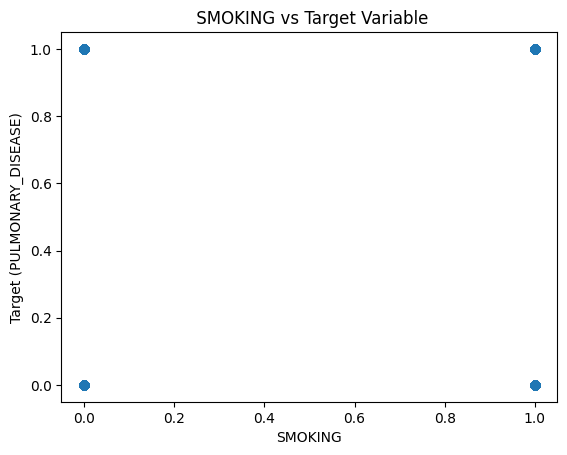

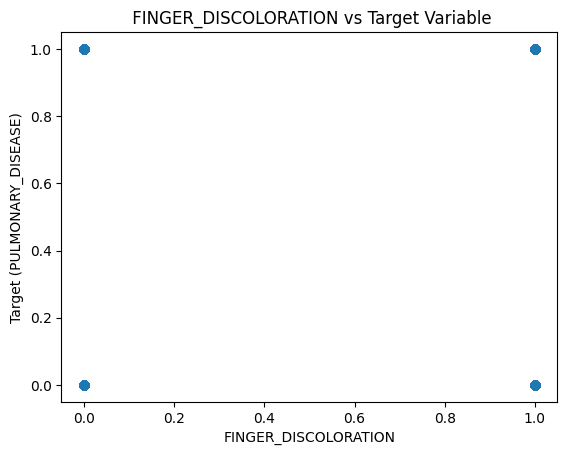

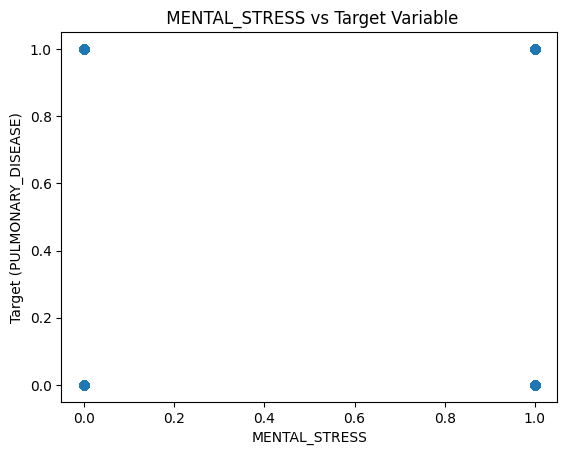

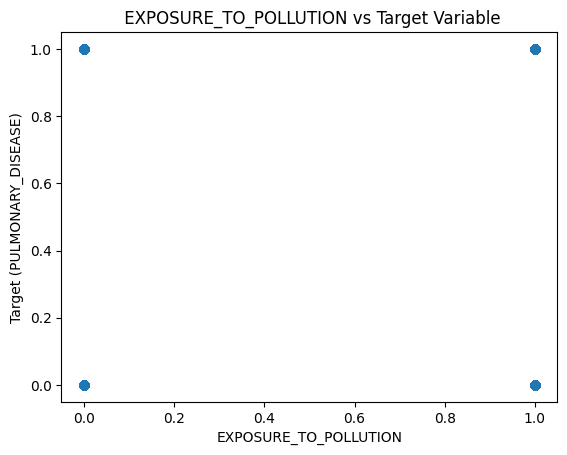

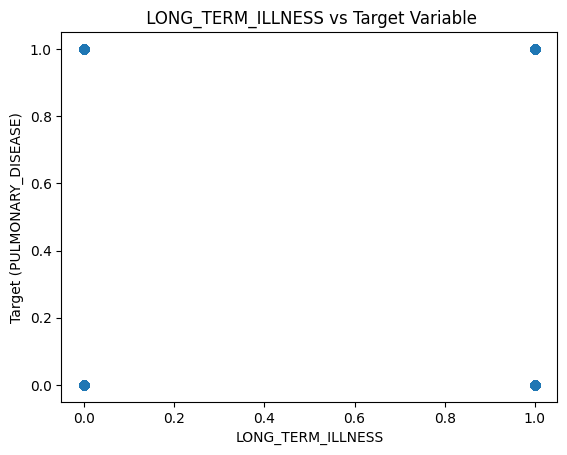

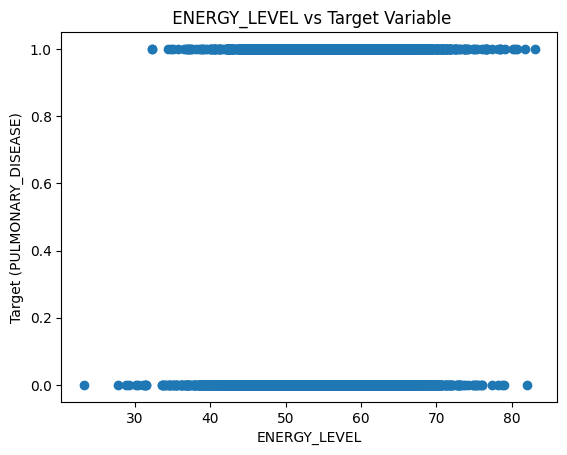

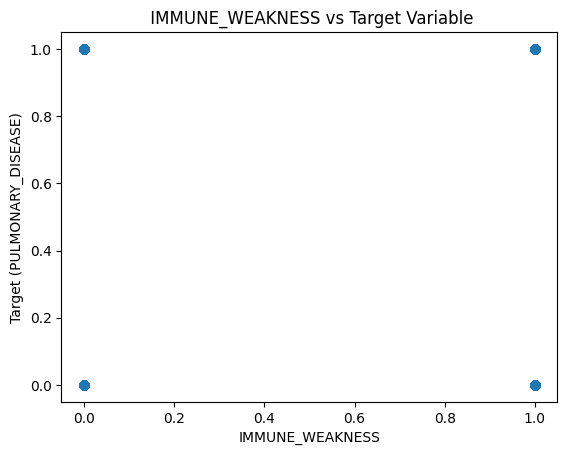

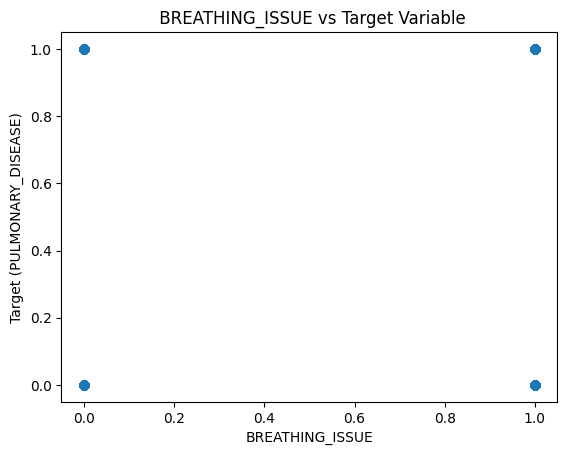

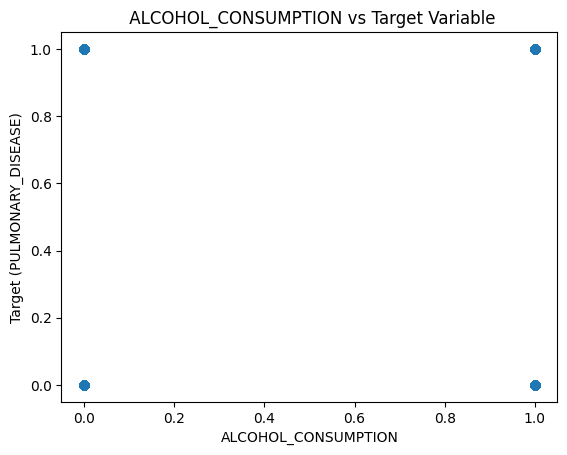

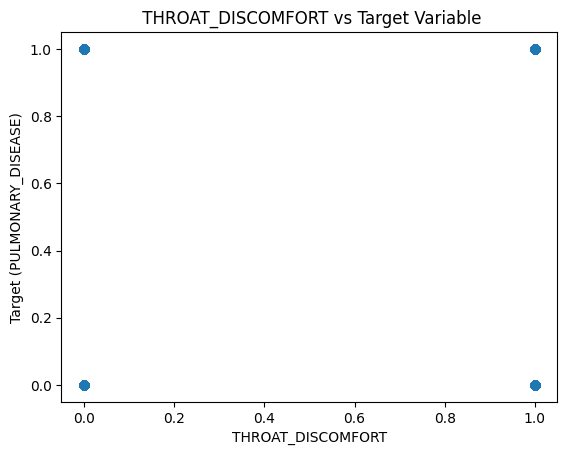

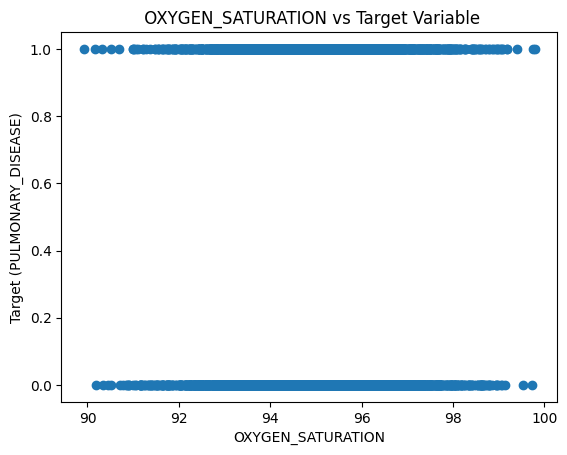

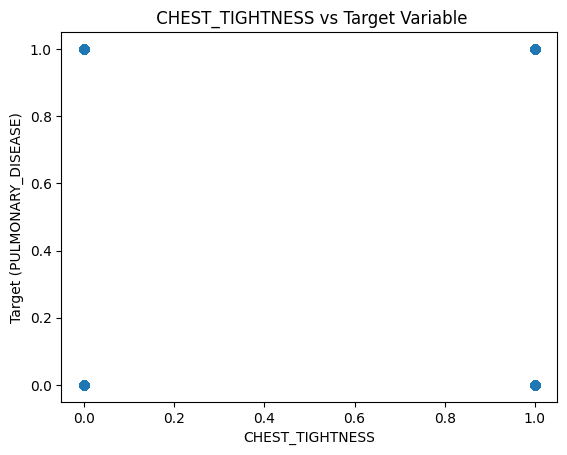

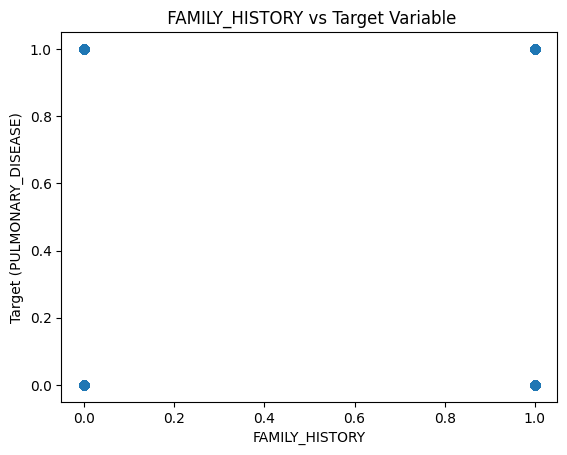

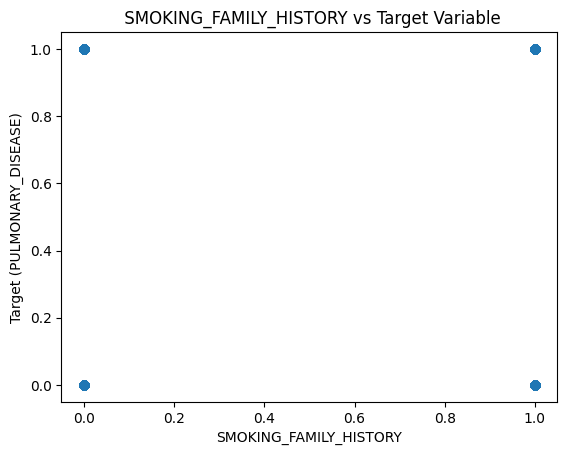

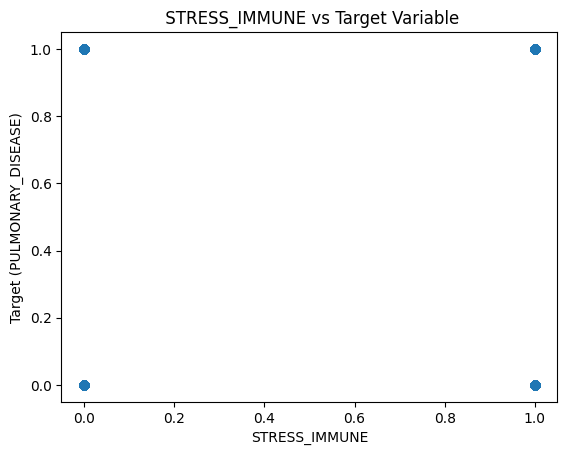

In [3]:
#Features vs Target
plt.figure(figsize=(10, 6))
for column in X_toScale.columns:
    plt.scatter(X_toScale[column], y, label=column)
    plt.xlabel(column)
    plt.ylabel('Target (PULMONARY_DISEASE)')
    plt.title(f' {column} vs Target Variable')
    plt.show()


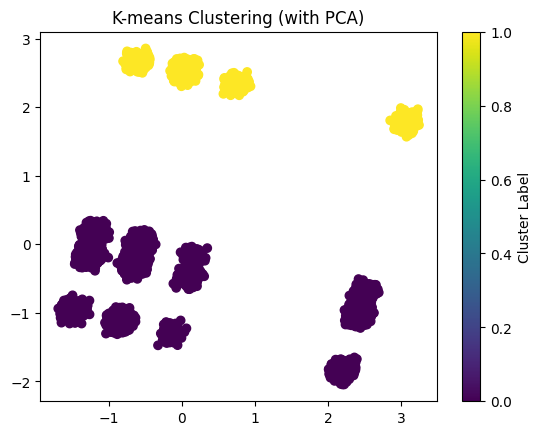

In [10]:
#Kmeans Clustering with PCA (2 Clusters in 2D)

kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
df['cluster'] = kmeans.labels_

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])

plt.title('K-means Clustering (with PCA)')
plt.colorbar(label='Cluster Label')
plt.show()

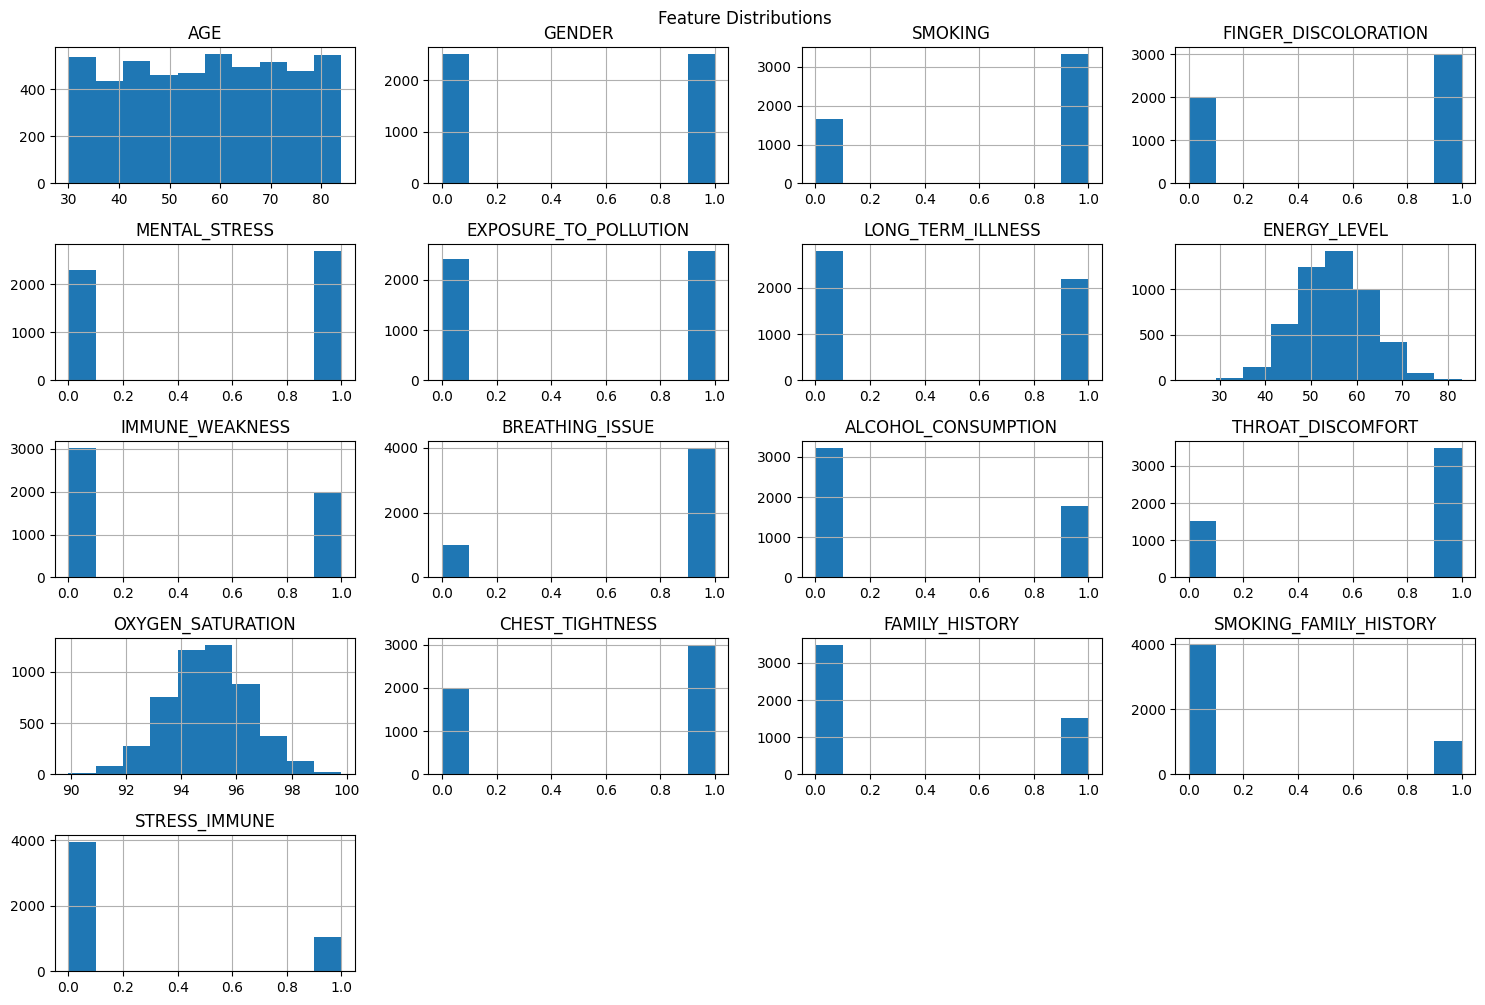

In [11]:
#Feature Distribution

X_toScale.hist(figsize=(15, 10))
plt.tight_layout()
plt.suptitle('Feature Distributions', y=1)
plt.show()

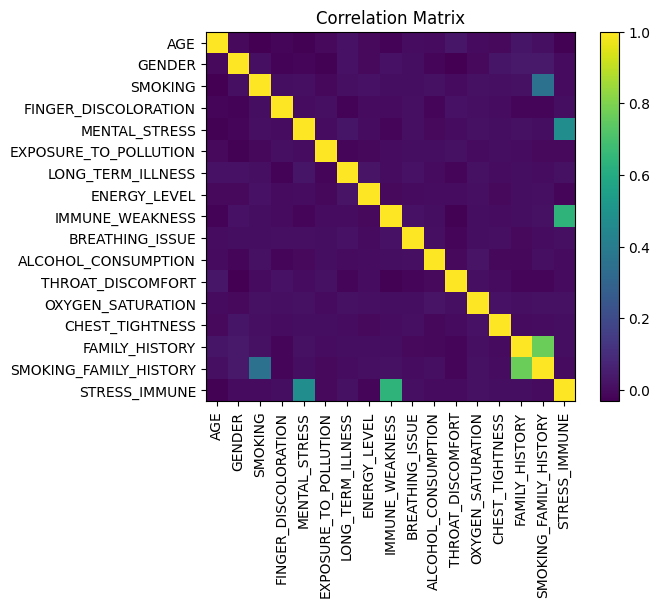

In [15]:
#Correlation Matrix
matrix = X_toScale.corr()
plt.imshow(matrix)

plt.colorbar()

plt.xticks(range(len(matrix)), X_toScale.columns, rotation=90)
plt.yticks(range(len(matrix)),  X_toScale.columns)

plt.title('Correlation Matrix')
plt.show()
